In [1]:
# 🚀 XGBoost Özet Notlar

* **Nedir?** Karar ağaçlarını sıralı eğiterek hatalardan öğrenen (*Boosting*) en güçlü tablosal veri algoritmasıdır.

### ⚡ Klasik Gradient Boosting'den Farkları:
1. **Çok Hızlı:** Paralel hesaplama (**multithreading**) yapar.
2. **Ezberlemez:** Dahili **L1 / L2 Regularization** ile overfitting'i engeller.
3. **Eksik Veri Dostu:** `NaN` / boş değerleri otomatik halleder.
4. **Hassas Matematik:** Hata optimizasyonunda hem **1. hem 2. türevi** (Gradient + Hessian) kullanır.

SyntaxError: unterminated string literal (detected at line 7) (3930750660.py, line 7)

In [53]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [54]:
df = pd.read_csv('20-digitalskysurvey (2).csv')

In [55]:
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      10000 non-null  float64
 1   ra         10000 non-null  float64
 2   dec        10000 non-null  float64
 3   u          10000 non-null  float64
 4   g          10000 non-null  float64
 5   r          10000 non-null  float64
 6   i          10000 non-null  float64
 7   z          10000 non-null  float64
 8   run        10000 non-null  int64  
 9   rerun      10000 non-null  int64  
 10  camcol     10000 non-null  int64  
 11  field      10000 non-null  int64  
 12  specobjid  10000 non-null  float64
 13  class      10000 non-null  object 
 14  redshift   10000 non-null  float64
 15  plate      10000 non-null  int64  
 16  mjd        10000 non-null  int64  
 17  fiberid    10000 non-null  int64  
dtypes: float64(10), int64(7), object(1)
memory usage: 1.4+ MB


In [57]:
df.describe()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,redshift,plate,mjd,fiberid
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.237650e+18,175.529987,14.836148,18.619355,17.371931,16.840963,16.583579,16.422833,981.034800,301.0,3.648700,302.380100,1.645022e+18,0.143726,1460.986400,52943.533300,353.069400
std,1.577039e+05,47.783439,25.212207,0.828656,0.945457,1.067764,1.141805,1.203188,273.305024,0.0,1.666183,162.577763,2.013998e+18,0.388774,1788.778371,1511.150651,206.298149
min,1.237650e+18,8.235100,-5.382632,12.988970,12.799550,12.431600,11.947210,11.610410,308.000000,301.0,1.000000,11.000000,2.995780e+17,-0.004136,266.000000,51578.000000,1.000000
25%,1.237650e+18,157.370946,-0.539035,18.178035,16.815100,16.173333,15.853705,15.618285,752.000000,301.0,2.000000,184.000000,3.389248e+17,0.000081,301.000000,51900.000000,186.750000
50%,1.237650e+18,180.394514,0.404166,18.853095,17.495135,16.858770,16.554985,16.389945,756.000000,301.0,4.000000,299.000000,4.966580e+17,0.042591,441.000000,51997.000000,351.000000
75%,1.237650e+18,201.547279,35.649397,19.259232,18.010145,17.512675,17.258550,17.141447,1331.000000,301.0,5.000000,414.000000,2.881300e+18,0.092579,2559.000000,54468.000000,510.000000
max,1.237650e+18,260.884382,68.542265,19.599900,19.918970,24.802040,28.179630,22.833060,1412.000000,301.0,6.000000,768.000000,9.468830e+18,5.353854,8410.000000,57481.000000,1000.000000


In [58]:
df.isnull().sum()

objid        0
ra           0
dec          0
u            0
g            0
r            0
i            0
z            0
run          0
rerun        0
camcol       0
field        0
specobjid    0
class        0
redshift     0
plate        0
mjd          0
fiberid      0
dtype: int64

In [59]:
# kagglede verimizide ki kolnalari arastirmamiz gerek cok detayli konular var bizim amacimiz siniflandirma olucak ondan dolayi
# siniflandirmada onemli olan kolanalarimiza odaklanacaz 


In [60]:
drop_data = ['objid','specobjid','camcol','field','rerun','run']

In [61]:
df.drop(drop_data,axis=1,inplace=True)

In [62]:
df.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,STAR,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,STAR,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,GALAXY,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,STAR,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,STAR,0.000590,3306,54922,512


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   class     10000 non-null  object 
 8   redshift  10000 non-null  float64
 9   plate     10000 non-null  int64  
 10  mjd       10000 non-null  int64  
 11  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 937.6+ KB


In [64]:
df['class'].value_counts()

class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64

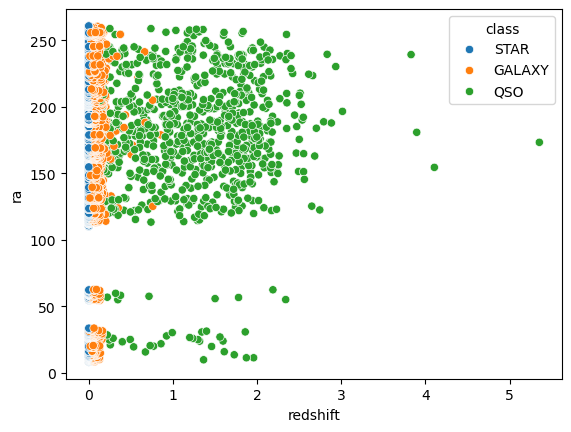

In [65]:
sns.scatterplot(data=df,x='redshift',y='ra',hue='class')
plt.show()

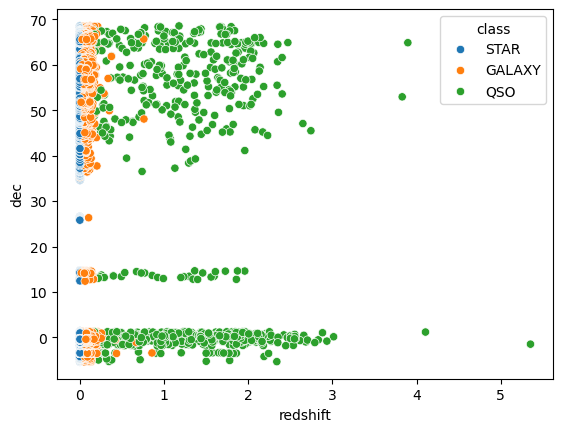

In [66]:
sns.scatterplot(data=df,x='redshift',y='dec',hue='class')
plt.show()

In [67]:
# redshift in cok onemli oldugunu gorduk siniflandirma icin

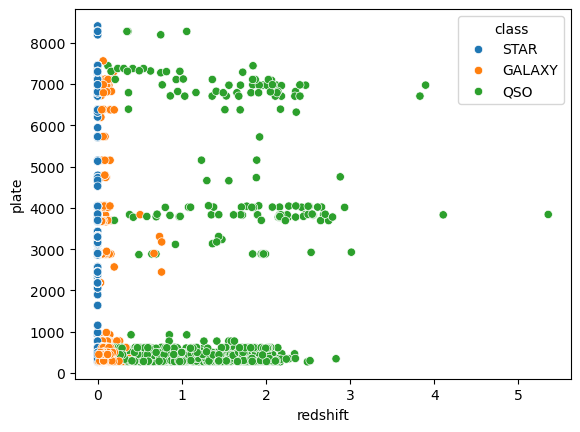

In [68]:
sns.scatterplot(data=df,x='redshift',y='plate',hue='class')
plt.show()

In [69]:
from sklearn.preprocessing import LabelEncoder

In [70]:
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [71]:
df.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,2,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,2,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,0,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,2,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,2,0.000590,3306,54922,512


In [72]:
df.corr()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
ra,1.000000,0.003596,0.031238,0.043909,0.047103,0.045731,0.042950,-0.043219,0.030307,-0.095329,-0.086887,0.057485
dec,0.003596,1.000000,0.035279,0.061875,0.063404,0.058292,0.056870,-0.058918,0.067021,0.088342,0.066147,0.155012
u,0.031238,0.035279,1.000000,0.849232,0.692379,0.602630,0.551483,-0.269044,0.163741,-0.129430,-0.168793,0.011301
g,0.043909,0.061875,0.849232,1.000000,0.958106,0.907419,0.879622,-0.099212,0.407576,-0.054981,-0.092772,0.047187
r,0.047103,0.063404,0.692379,0.958106,1.000000,0.977672,0.969197,0.049628,0.441080,0.019787,-0.009345,0.061081
i,0.045731,0.058292,0.602630,0.907419,0.977672,1.000000,0.981507,0.146791,0.431450,0.072958,0.050896,0.069977
z,0.042950,0.056870,0.551483,0.879622,0.969197,0.981507,1.000000,0.215758,0.424034,0.112397,0.095658,0.067980
class,-0.043219,-0.058918,-0.269044,-0.099212,0.049628,0.146791,0.215758,1.000000,-0.075510,0.585495,0.648768,0.053593
redshift,0.030307,0.067021,0.163741,0.407576,0.441080,0.431450,0.424034,-0.075510,1.000000,-0.038091,-0.057957,0.046532
plate,-0.095329,0.088342,-0.129430,-0.054981,0.019787,0.072958,0.112397,0.585495,-0.038091,1.000000,0.966881,0.229811


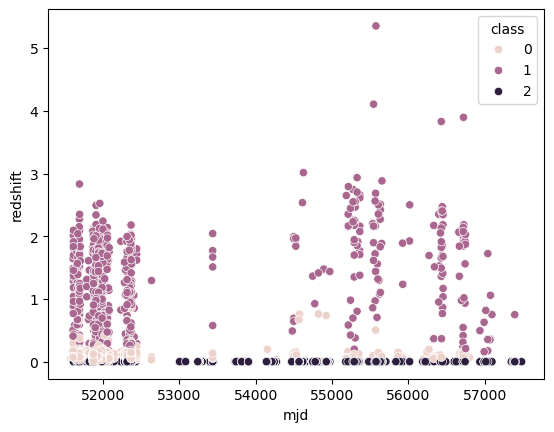

In [73]:
sns.scatterplot(data=df,x='mjd',y='redshift',hue='class')
plt.show()

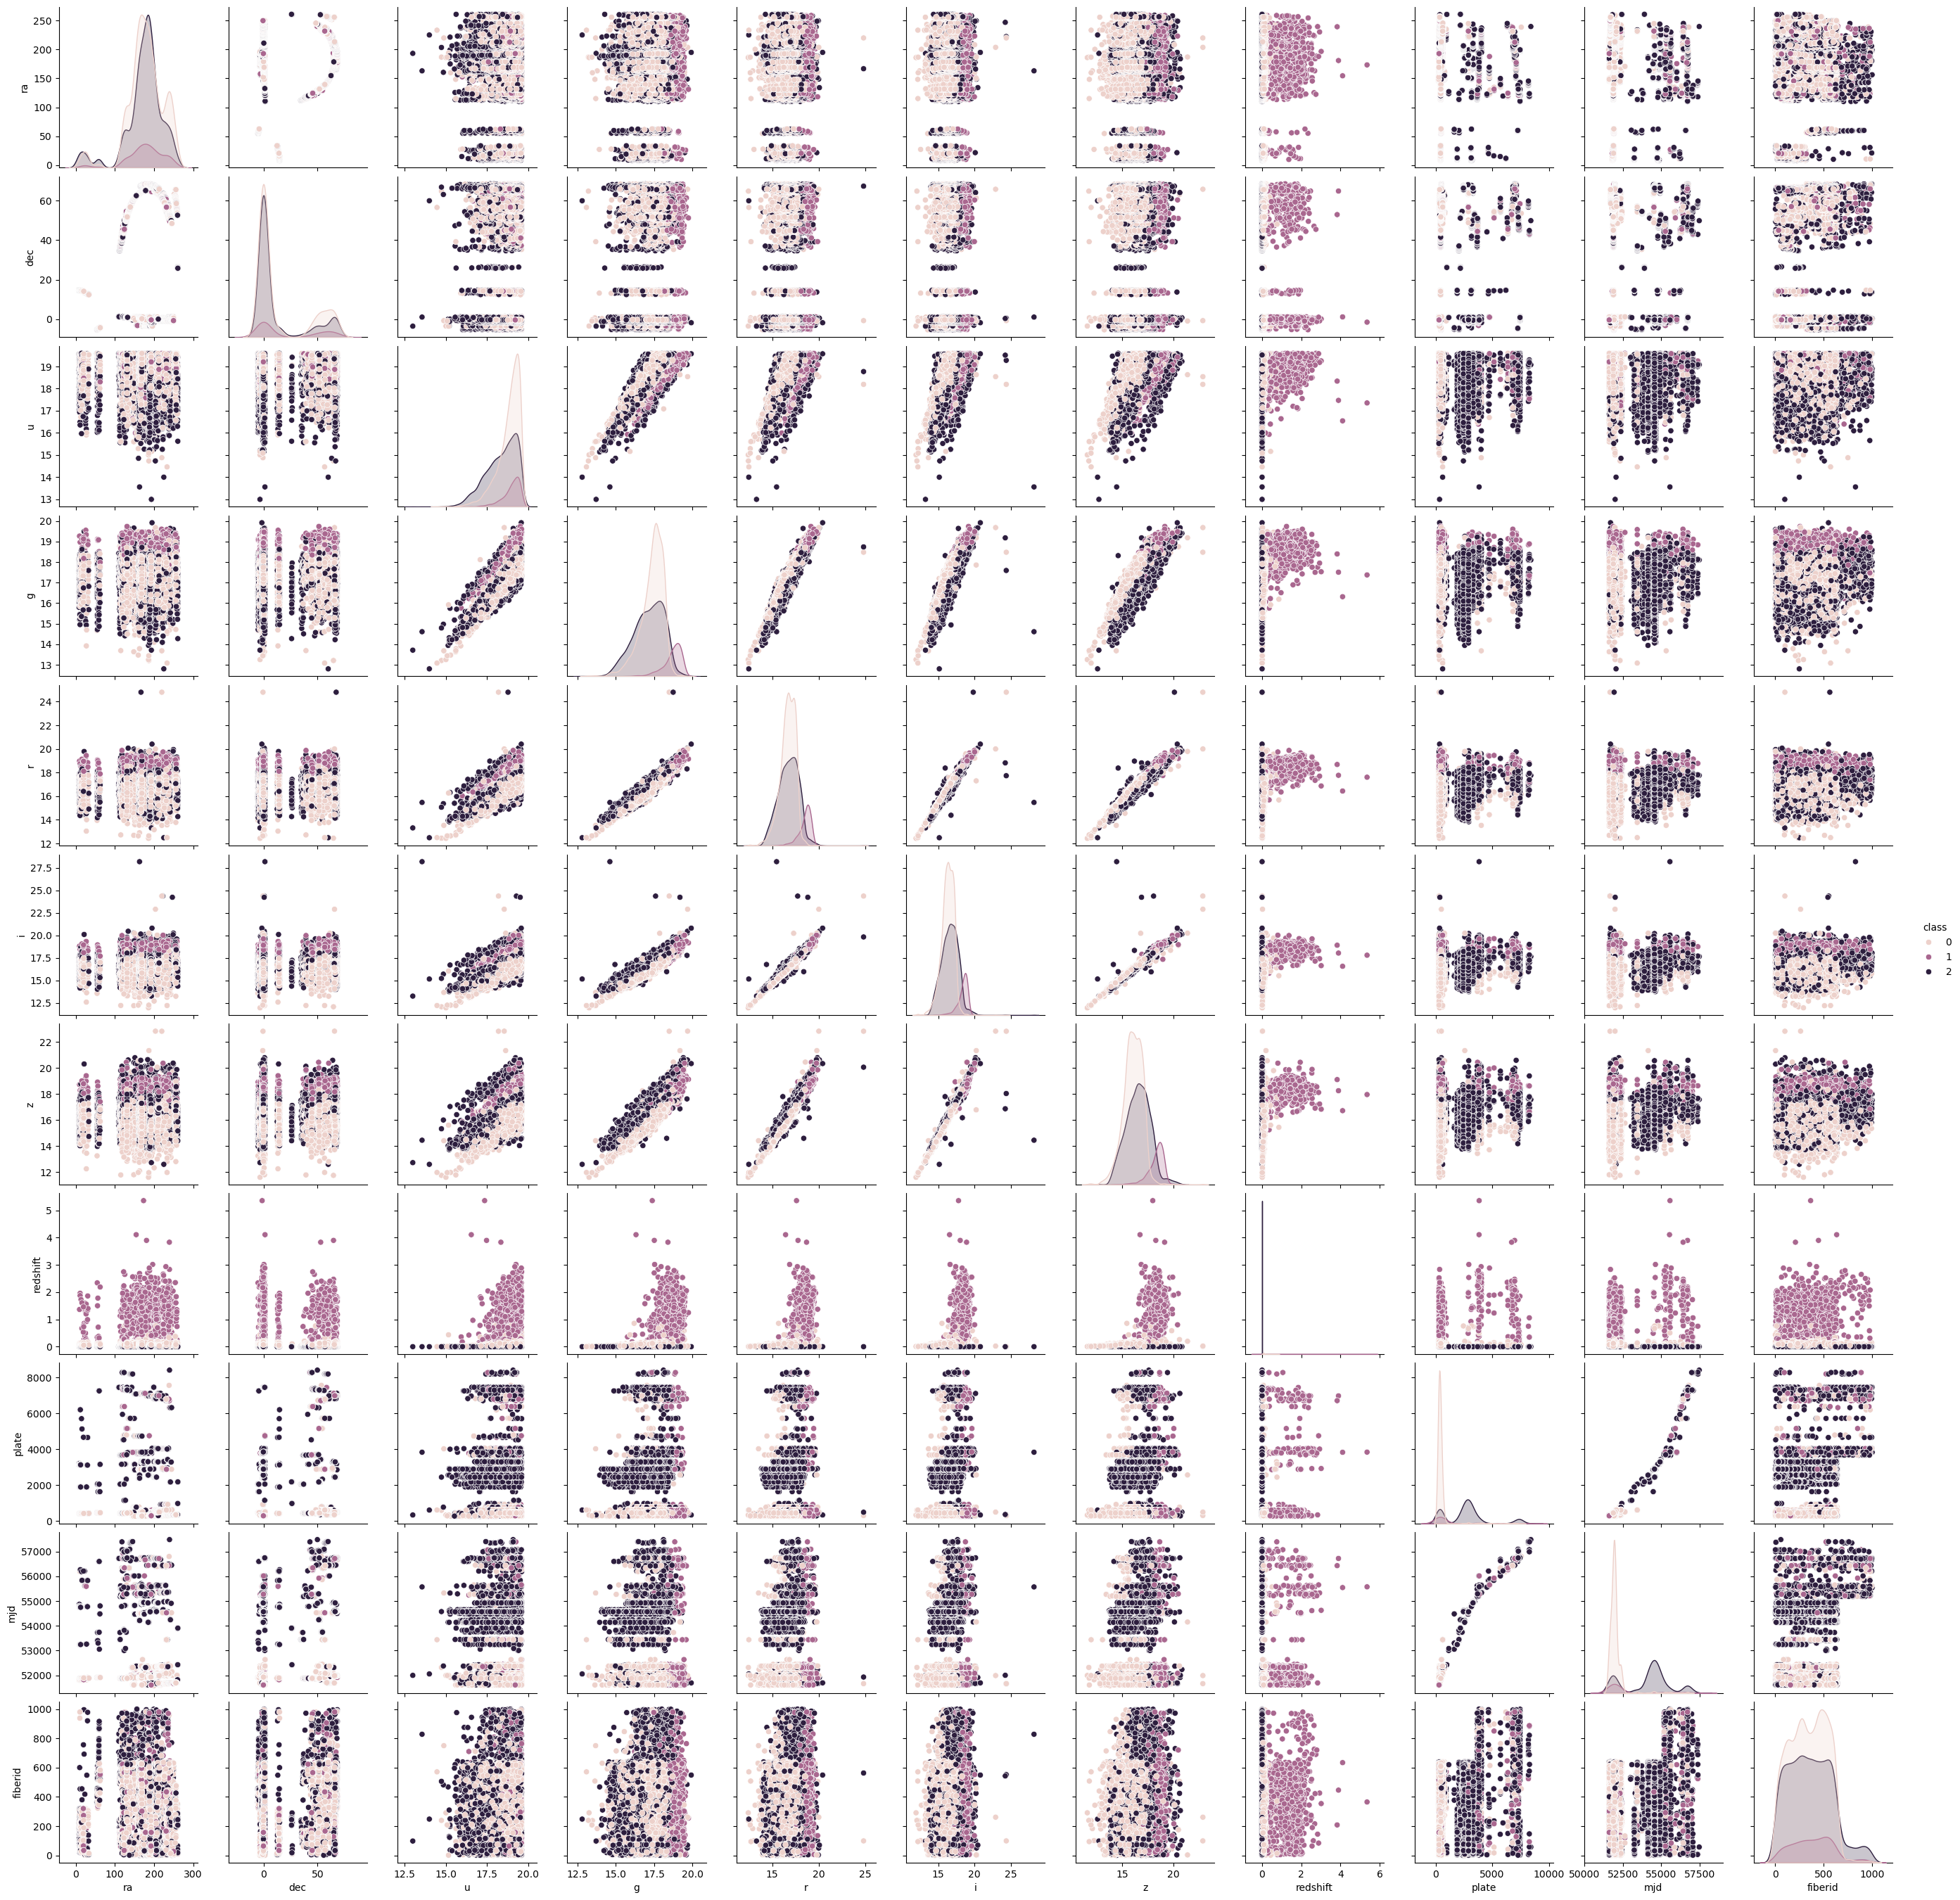

In [74]:
sns.pairplot(df,hue='class')
plt.show()

TypeError: can't multiply sequence by non-int of type 'function'

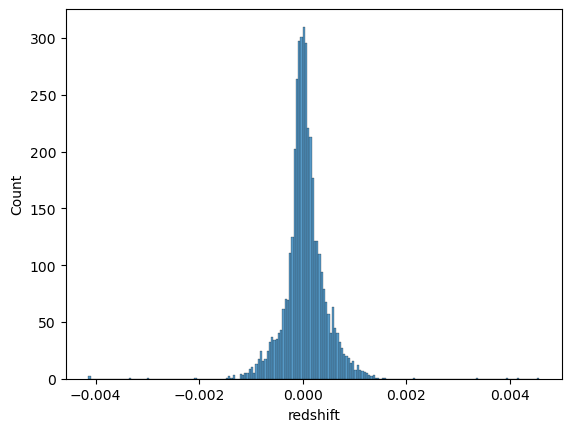

In [75]:
sns.histplot(df[df['class'] == 2 ].redshift)
plt.show*()

In [76]:
# 0 1 ve 2 yi yan ya gormek istiyorum

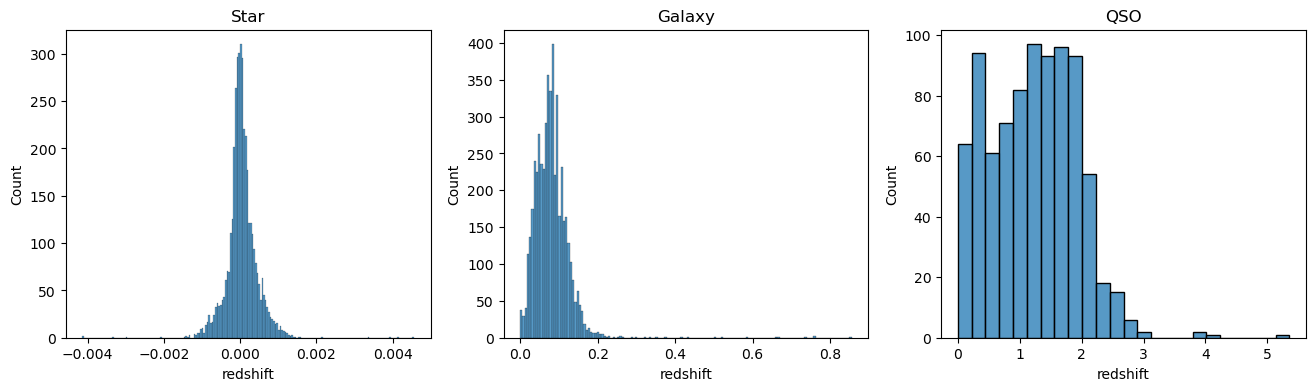

In [80]:
fig , axes = plt.subplots(nrows=1,ncols=3,figsize=(16,4))
ax = sns.histplot(df[df['class'] == 2 ].redshift,ax=axes[0])
ax.set_title('Star')
ax = sns.histplot(df[df['class'] == 0 ].redshift,ax=axes[1])
ax.set_title('Galaxy')
ax = sns.histplot(df[df['class'] == 1 ].redshift,ax= axes[2])
ax.set_title('QSO')
plt.show()

In [81]:
df['class'].value_counts()

class
0    4998
2    4152
1     850
Name: count, dtype: int64

In [82]:
X = df.drop('class',axis=1)
y= df['class']

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [86]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=15)

In [87]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   -- ------------------------------------- 3.9/69.5 MB 16.1 MB/s eta 0:00:05
   ----- ---------------------------------- 10.0/69.5 MB 21.6 MB/s eta 0:00:03
   --------- ------------------------------ 15.7/69.5 MB 23.4 MB/s eta 0:00:03
   ------------ --------------------------- 21.2/69.5 MB 24.3 MB/s eta 0:00:02
   --------------- ------------------------ 26.7/69.5 MB 24.8 MB/s eta 0:00:02
   ------------------ --------------------- 32.8/69.5 MB 25.2 MB/s eta 0:00:02
   ---------------------- ----------------- 38.3/69.5 MB 25.5 MB/s eta 0:00:02
   ------------------------- -------------- 43.8/69.5 MB 25.7 MB/s eta 0:00:02
   ---------------------------- ----------- 49.5/69.5 MB 25.9 MB/s eta 0:00:01
   ------------------------------- -------- 55.6/69.5 MB 26.0 MB/s eta 0:00:01
   ----------------------------------- ---- 61.3/69.5 MB 26.1 MB/s eta 

In [89]:
from xgboost import XGBClassifier

In [91]:
xgb = XGBClassifier(n_estimators=100)
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)

In [92]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [93]:
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[1666   16    3]
 [  14  254    0]
 [   7    1 1339]]
0.9875757575757576
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1685
           1       0.94      0.95      0.94       268
           2       1.00      0.99      1.00      1347

    accuracy                           0.99      3300
   macro avg       0.97      0.98      0.98      3300
weighted avg       0.99      0.99      0.99      3300



In [94]:
# cok yuksek cikti zaten cikacagi belliydi grafiklerden beli oluyordu 

In [95]:
# hyperparametre tuning 

In [96]:
params = {
    'n_estimators':[100,200,300,500],
    'learning_rate':[0.01,0.1],
    'max_depth':[5,8,12,20,30],
    'colsample_bytree':[0.3,0.4,0.5,0.8,1]
}

In [97]:
from sklearn.model_selection import GridSearchCV

In [99]:
grid = GridSearchCV(estimator=XGBClassifier(),param_grid=params,cv=5,n_jobs=-1)

In [ ]:
grid.fit(X_train,y_train)

In [ ]:
grid.best_params_